# Food Demand Forecasting Project

### Week-1

In [1]:
## Importing Libraries
%pip install pandas matplotlib seaborn numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\vaide\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
## Loading Dataset
df = pd.read_csv('C:\\Users\\vaide\\OneDrive\\Documents\\GitHub\\ai-grievance-system\\data\\train.csv')
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
0,1379560,1,55,1885,136.83,152.29,0,0,177
1,1466964,1,55,1993,136.83,135.83,0,0,270
2,1346989,1,55,2539,134.86,135.86,0,0,189
3,1338232,1,55,2139,339.50,437.53,0,0,54
4,1448490,1,55,2631,243.50,242.50,0,0,40


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 31.3 MB


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders
count,4.565480e+05,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.000000,456548.00000,456548.000000
mean,1.250096e+06,74.768771,82.105796,2024.337458,332.238933,354.156627,0.081152,0.10920,261.872760
std,1.443548e+05,41.524956,45.975046,547.420920,152.939723,160.715914,0.273069,0.31189,395.922798
min,1.000000e+06,1.000000,10.000000,1062.000000,2.970000,55.350000,0.000000,0.00000,13.000000
25%,1.124999e+06,39.000000,43.000000,1558.000000,228.950000,243.500000,0.000000,0.00000,54.000000
50%,1.250184e+06,76.000000,76.000000,1993.000000,296.820000,310.460000,0.000000,0.00000,136.000000
75%,1.375140e+06,111.000000,110.000000,2539.000000,445.230000,458.870000,0.000000,0.00000,324.000000
max,1.499999e+06,145.000000,186.000000,2956.000000,866.270000,866.270000,1.000000,1.00000,24299.000000


In [4]:
## Converting date column
df['week'] = pd.to_datetime(df['week'])
df = df.sort_values('week')

### EDA

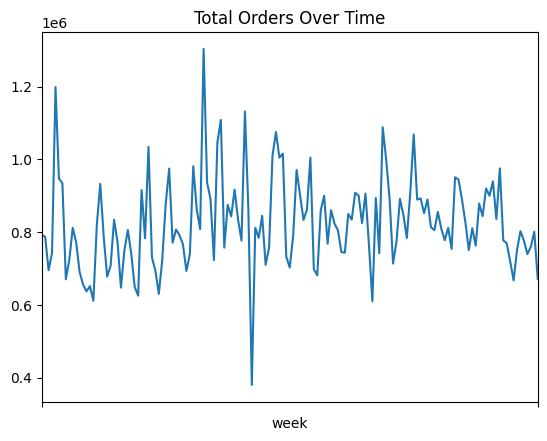

In [5]:
## Sales Trend Over TIme
plt.figure()
df.groupby('week')['num_orders'].sum().plot()
plt.title("Total Orders Over Time")
plt.show()

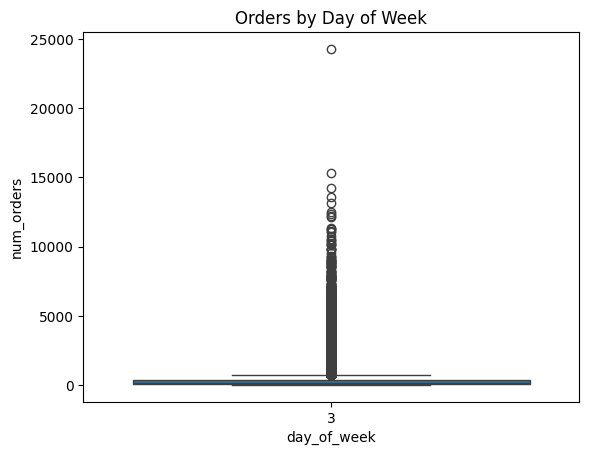

In [6]:
## Orders by Day of Week
df['day_of_week'] = df['week'].dt.dayofweek
sns.boxplot(x='day_of_week', y='num_orders', data=df)
plt.title("Orders by Day of Week")
plt.show()

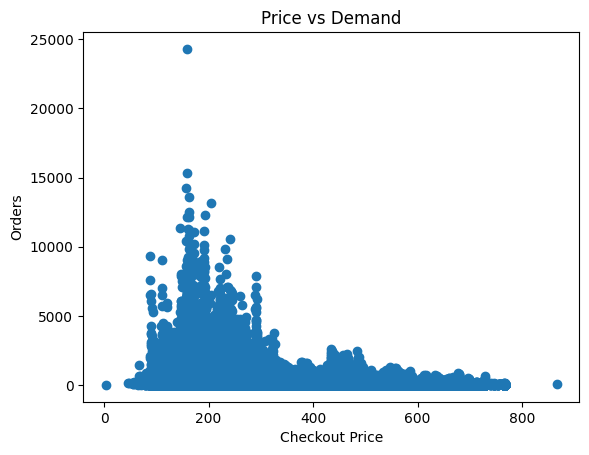

In [7]:
## Price Vs Demand
plt.scatter(df['checkout_price'], df['num_orders'])
plt.xlabel("Checkout Price")
plt.ylabel("Orders")
plt.title("Price vs Demand")
plt.show()

## Week-2

### Feature Engineering

In [8]:
df['month'] = df['week'].dt.month
df['week_of_year'] = df['week'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

df['lag_7'] = df['num_orders'].shift(7)
df['lag_14'] = df['num_orders'].shift(14)

df['rolling_mean_7'] = df['num_orders'].rolling(7).mean()

df.dropna(inplace=True)

df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,day_of_week,month,week_of_year,is_weekend,lag_7,lag_14,rolling_mean_7
1956,1307232,1970-01-01 00:00:00.000000001,67,1230,321.07,389.00,0,0,175,3,1,1,0,136.0,177.0,233.000000
1957,1286510,1970-01-01 00:00:00.000000001,67,2322,323.04,385.09,0,0,432,3,1,1,0,53.0,80.0,287.142857
1958,1140580,1970-01-01 00:00:00.000000001,67,2290,287.15,286.15,0,0,730,3,1,1,0,107.0,82.0,376.142857
1959,1304022,1970-01-01 00:00:00.000000001,67,1727,433.65,433.65,0,0,865,3,1,1,0,26.0,13.0,496.000000
1960,1438088,1970-01-01 00:00:00.000000001,67,1109,240.62,268.69,1,0,998,3,1,1,0,555.0,1958.0,559.285714


In [9]:
## Preparing Features
features = ['day_of_week','month','week_of_year','is_weekend',
            'lag_7','lag_14','rolling_mean_7']

X = df[features]
y = df['num_orders']

In [10]:
X.head()

,day_of_week,month,week_of_year,is_weekend,lag_7,lag_14,rolling_mean_7
1956,3,1,1,0,136.0,177.0,233.000000
1957,3,1,1,0,53.0,80.0,287.142857
1958,3,1,1,0,107.0,82.0,376.142857
1959,3,1,1,0,26.0,13.0,496.000000
1960,3,1,1,0,555.0,1958.0,559.285714


In [11]:
y.head()

1956    175
1957    432
1958    730
1959    865
1960    998
Name: num_orders, dtype: int64

In [12]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Week-3

### Model Training

In [13]:
%pip install xgboost

from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\vaide\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### Prediction

In [14]:
y_pred = model.predict(X_test)

## Week-4

### Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 206.9150390625
RMSE: 364.9653665075633


### Actual Vs Prediction

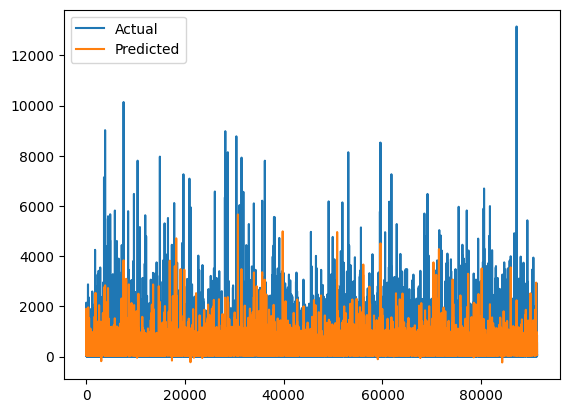

In [16]:
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

### Feature Importance

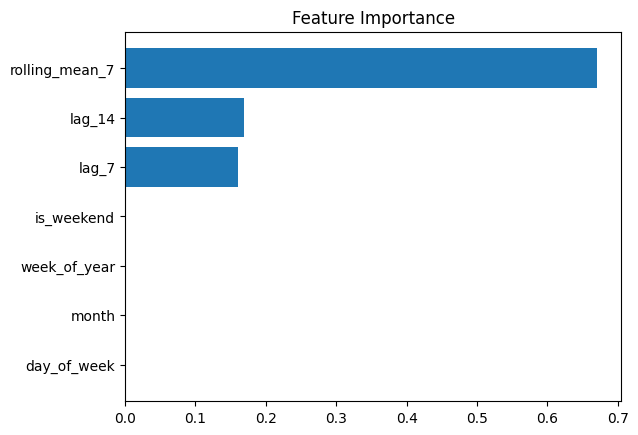

In [17]:
plt.barh(features, model.feature_importances_)
plt.title("Feature Importance")
plt.show()